In [ ]:
file_path = "Data_Hydak/After_3h.dat"

with open(file_path, 'r', encoding='latin1') as f:
    for i in range(10):
        print(f"Line {i}: {repr(f.readline())}")

In [ ]:
import os
import pandas as pd

file_path = os.path.join("Data_Hydak", "After_3h.dat")

skip_rows = 0
with open(file_path, 'r', encoding='latin1') as f:
    for idx, line in enumerate(f):
        if 'Date' in line or 'Time' in line or (line.strip() and line.strip()[0].isdigit() and '\t' in line):
            skip_rows = idx
            break

print(f"Skipping {skip_rows} metadata header lines...")

try:
    df = pd.read_csv(file_path, sep='\t', skiprows=skip_rows, encoding='latin1')
    print("Data loaded successfully!")
    display(df.head())
except Exception as e:
    print(f"Parsing error: {e}")
    

In [ ]:
import os

labview_path = "Data_Labview"

if os.path.exists(labview_path):
    print("--- Folders/Files found inside Data_Labview ---")
    items = os.listdir(labview_path)
    for item in items:
        print(item)
else:
    print("Could not find the Data_Labview folder!")

In [ ]:
subfolder_path = os.path.join("Data_Labview", "After_3h")

if os.path.exists(subfolder_path):
    print("--- Files inside Data_Labview/After_3h ---")
    print(os.listdir(subfolder_path))
else:
    print(f"Path '{subfolder_path}' not found, let's check your directory structure first.")

In [ ]:
import os
import scipy.io

# Path to MATLAB data file
mat_file_path = os.path.join("Data_Labview", "After_3h", "data(1).mat")

if os.path.exists(mat_file_path):
    # Load the .mat file
    mat_data = scipy.io.loadmat(mat_file_path)
    
    
    sensor_keys = [key for key in mat_data.keys() if not key.startswith('__')]
    print("Variables/Sensors found inside the file:\n", sensor_keys)
else:
    print("Could not find the specified .mat file!")

In [ ]:
import os
import scipy.io
import pandas as pd

# Path to LabVIEW MATLAB file
mat_file_path = os.path.join("Data_Labview", "After_3h", "data(1).mat")

# Load the file matrices
mat_data = scipy.io.loadmat(mat_file_path)

# Extract and flatten 4 sensor keys into columns
data_dict = {
    "Force": mat_data["Force"].flatten(),
    "Kontakt_V": mat_data["Kontakt_V"].flatten(),
    "Rotation_speed": mat_data["Rotation_speed"].flatten(),
    "Torque": mat_data["Torque"].flatten()
}

# Convert it into a clean data frame
df_bearing = pd.DataFrame(data_dict)

print("Data Matrix Rows & Columns:", df_bearing.shape)
print("\n--- Raw Sensor Data Preview ---")
display(df_bearing.head(10))

In [ ]:
import os
import scipy.io
import numpy as np

#compare early life vs late life data matrices
early_file = os.path.join("Data_Labview", "After_3h", "data(1).mat")
late_file = os.path.join("Data_Labview", "After_60h", "data(1).mat")

for label, path in [("Early (3h)", early_file), ("Late (60h)", late_file)]:
    if os.path.exists(path):
        mat = scipy.io.loadmat(path)
        v_data = mat["Kontakt_V"].flatten()
        force_data = mat["Force"].flatten()
        
        print(f"=== {label} Health Analysis ===")
        print(f"  Minimum Contact Voltage: {v_data.min():.4f} V")
        print(f"  Average Contact Voltage: {v_data.mean():.4f} V")
        print(f"  Maximum Friction Force:  {force_data.max():.4f}")
        print("-" * 35)

In [ ]:
import os
import scipy.io
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- 1. FEATURE EXTRACTION ---
def extract_features_from_folder(folder_name, label_value, window_size=5000):
    folder_path = os.path.join("Data_Labview", folder_name)
    feature_list = []
    
    if not os.path.exists(folder_path):
        print(f"Warning: Folder {folder_name} not found.")
        return []
        
    # Take the first 5 .mat files to process a quick batch
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.mat')][:5]
    
    for file_name in all_files:
        file_path = os.path.join(folder_path, file_name)
        mat = scipy.io.loadmat(file_path)
        
        v = mat["Kontakt_V"].flatten()
        f = mat["Force"].flatten()
        t = mat["Torque"].flatten()
        
        # Chop high-frequency arrays into time-windows to extract mathematical signatures
        for i in range(0, len(v) - window_size, window_size):
            v_win = v[i : i + window_size]
            f_win = f[i : i + window_size]
            t_win = t[i : i + window_size]
            
            features = {
                "v_mean": v_win.mean(),
                "v_min": v_win.min(),
                "v_std": v_win.std(),
                "f_mean": f_win.mean(),
                "f_max": f_win.max(),
                "t_mean": t_win.mean(),
                "t_max": t_win.max(),
                "is_failing": label_value  # 0 = Healthy (3h), 1 = Failing (60h)
            }
            feature_list.append(features)
            
    return feature_list

print("Converting raw high-speed sensor streams into window vectors...")
data_rows = extract_features_from_folder("After_3h", label_value=0) + \
            extract_features_from_folder("After_60h", label_value=1)

df_ml = pd.DataFrame(data_rows)
print(f"Dataset compiled! Matrix shape: {df_ml.shape}")

# 2. TRAIN MACHINE LEARNING PATTERNS 
X = df_ml.drop(columns=["is_failing"])
y = df_ml["is_failing"]

# Split data: 80% to learn patterns, 20% to quiz the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Check diagnostic performance
y_pred = model.predict(X_test)
print(f"\n🎉 Model Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Metrics Report:\n", classification_report(y_test, y_pred))

Converting raw high-speed sensor streams into window vectors...
Dataset compiled! Matrix shape: (390, 8)
Training Random Forest Classifier...

🎉 Model Accuracy Score: 98.72%

Classification Metrics Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        46
           1       0.97      1.00      0.98        32

    accuracy                           0.99        78
   macro avg       0.98      0.99      0.99        78
weighted avg       0.99      0.99      0.99        78



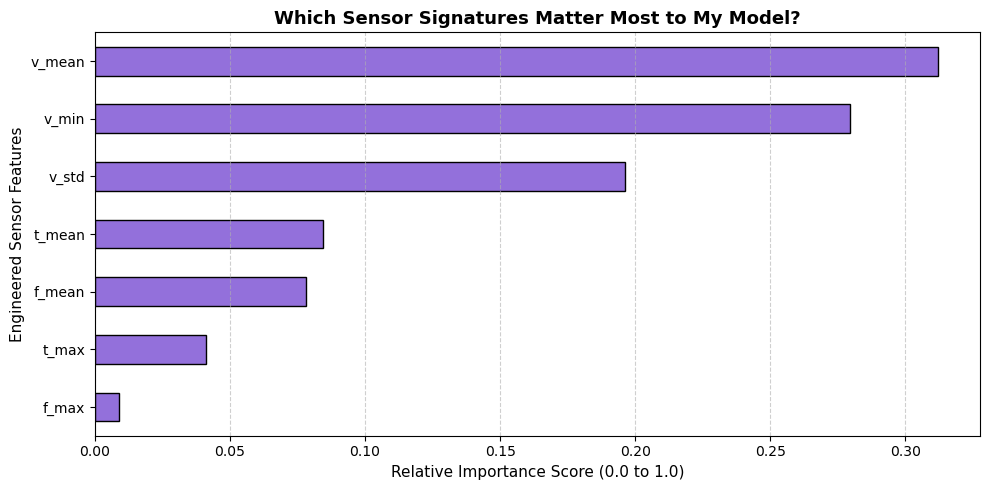

In [3]:
import os
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. PULLING PATTERN RATINGS ---
# I am grabbing the score weight that my Random Forest model gave to each feature
importances = model.feature_importances_
feature_names = X.columns

# I will sort these scores from the most important to least important
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# --- 2. CREATING MY PRESENTATION PLOT ---
# I am setting up a clean, presentation-sized chart window
plt.figure(figsize=(10, 5))

# I am making a horizontal bar chart so my label names are perfectly legible
forest_importances.plot(kind='barh', color='mediumpurple', edgecolor='black')

# I am configuring the titles and axis labels to ensure my presentation looks professional
plt.title("Which Sensor Signatures Matter Most to My Model?", fontsize=13, fontweight='bold')
plt.xlabel("Relative Importance Score (0.0 to 1.0)", fontsize=11)
plt.ylabel("Engineered Sensor Features", fontsize=11)

# I am putting my most powerful feature right at the very top of the chart
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.6)

# I am adjusting the layout and rendering my final chart
plt.tight_layout()
plt.show()